In [1]:

!pip install snntorch


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

In [3]:
import torch
import snntorch

print("PyTorch Version:", torch.__version__)
print("snnTorch Installed Successfully")

PyTorch Version: 2.12.0+cpu
snnTorch Installed Successfully


In [4]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.12.0+cpu
GPU Available: False


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Basic Transform (No Augmentation)

basic_transform = transforms.Compose([
    transforms.ToTensor()
])


# Shift Augmentation Transform

augment_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)   # shift up to 10%
    ),
    transforms.ToTensor()
])

# MNIST DATASETS

mnist_train = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

mnist_train_aug = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=augment_transform
)

mnist_test = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=basic_transform
)


# Fashion-MNIST DATASETS

fmnist_train = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

fmnist_train_aug = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=augment_transform
)

fmnist_test = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=basic_transform
)


# Data Loaders

batch_size = 128

mnist_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_aug_loader = DataLoader(mnist_train_aug, batch_size=batch_size, shuffle=True)

fmnist_loader = DataLoader(fmnist_train, batch_size=batch_size, shuffle=True)
fmnist_aug_loader = DataLoader(fmnist_train_aug, batch_size=batch_size, shuffle=True)

mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
fmnist_test_loader = DataLoader(fmnist_test, batch_size=batch_size, shuffle=False)

print("Datasets loaded successfully!")

Using device: cpu


100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%

Datasets loaded successfully!


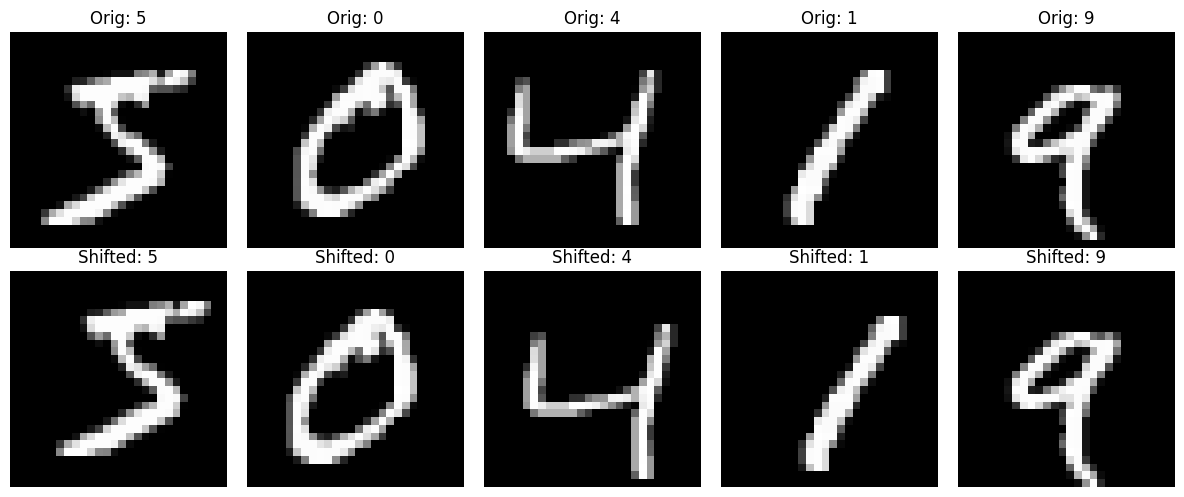

In [6]:
# Visualize original and augmented MNIST images

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i in range(5):

    # Original
    image, label = mnist_train[i]
    axes[0, i].imshow(image.squeeze(), cmap='gray')
    axes[0, i].set_title(f"Orig: {label}")
    axes[0, i].axis('off')

    # Augmented
    aug_image, aug_label = mnist_train_aug[i]
    axes[1, i].imshow(aug_image.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Shifted: {aug_label}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import snntorch as snn
from snntorch import spikegen

# Simulation parameters
num_steps = 25  # number of time steps

# Get one batch from MNIST loader
data_iter = iter(mnist_loader)
images, labels = next(data_iter)

# Move to device
images = images.to(device)
labels = labels.to(device)

# Flatten images: [batch, 1, 28, 28] -> [batch, 784]
images_flat = images.view(images.size(0), -1)


# Latency Encoding
# Clip pixel values to avoid all-ones causing spikes at every timestep
images_flat = images_flat.clamp(0, 1 - 1e-6)

spike_data = spikegen.latency(
    images_flat,
    num_steps=num_steps,
    normalize=True,
    linear=True
)

print("Original image shape:", images.shape)
print("Flattened shape:", images_flat.shape)
print("Spike data shape:", spike_data.shape)

Original image shape: torch.Size([128, 1, 28, 28])
Flattened shape: torch.Size([128, 784])
Spike data shape: torch.Size([25, 128, 784])


Total spikes for sample 0: 784 / 19600 possible
Sparsity: 96.00% of entries are zero (good: should be high)


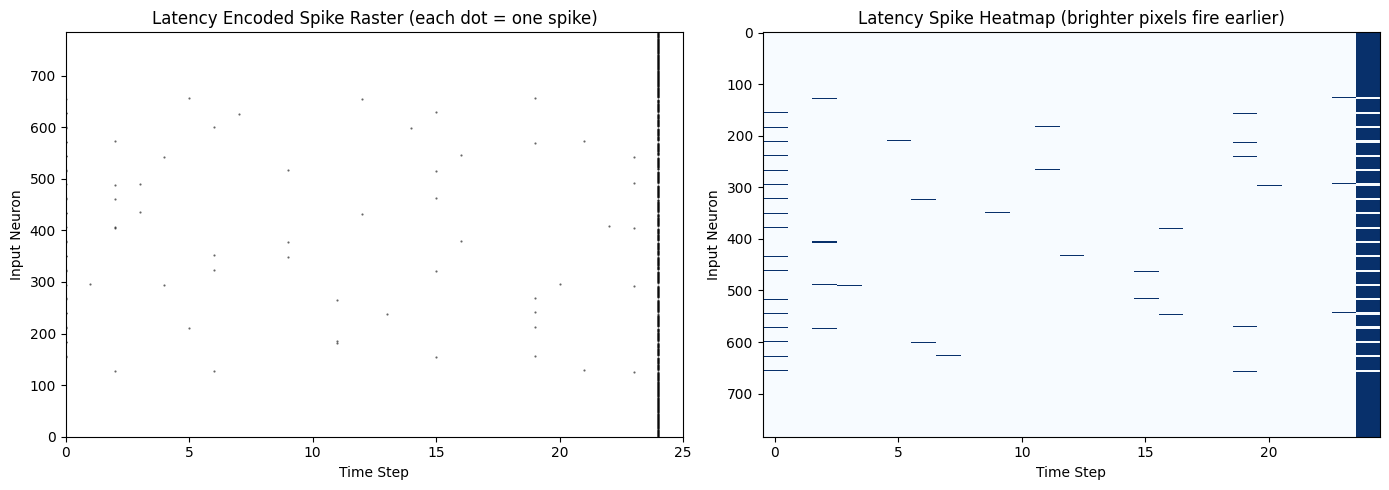

In [8]:
# Visualize spike activity for one sample (raster plot)
# Each dot = a single spike. Brighter pixels should spike earlier (low timestep)

sample_idx = 0

spike_sample = spike_data[:, sample_idx, :].cpu().numpy()  # [num_steps, 784]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raster scatter - shows individual spikes clearly
timesteps, neurons = spike_sample.nonzero()
axes[0].scatter(timesteps, neurons, s=0.3, c="black", alpha=0.6)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Input Neuron")
axes[0].set_title("Latency Encoded Spike Raster (each dot = one spike)")
axes[0].set_xlim(0, num_steps)
axes[0].set_ylim(0, 784)

# Right: imshow heatmap - shows temporal structure
axes[1].imshow(spike_sample.T, aspect="auto", cmap="Blues", interpolation="nearest")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Input Neuron")
axes[1].set_title("Latency Spike Heatmap (brighter pixels fire earlier)")

# Print spike statistics to verify encoding is correct
total_spikes = spike_sample.sum()
sparsity = 1 - (total_spikes / (spike_sample.shape[0] * spike_sample.shape[1]))
print(f"Total spikes for sample 0: {int(total_spikes)} / {spike_sample.shape[0] * spike_sample.shape[1]} possible")
print(f"Sparsity: {sparsity:.2%} of entries are zero (good: should be high)")

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import snntorch.functional as SF
from snntorch import surrogate


# Network Parameters

num_inputs = 784
num_hidden = 256
num_outputs = 10

beta = 0.95

# Surrogate gradient
spike_grad = surrogate.fast_sigmoid()


# Define Network

class SNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):

        # Initialize hidden states
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        # Loop through time steps
        for step in range(x.size(0)):

            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec), torch.stack(mem2_rec)


# Initialize Model

net = SNN().to(device)

print(net)

SNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (lif2): Leaky()
)


In [ ]:

# Forward Pass Test

# Use previously created spike_data
spk_out, mem_out = net(spike_data)

print("Spike Output Shape:", spk_out.shape)
print("Membrane Output Shape:", mem_out.shape)

Spike Output Shape: torch.Size([25, 128, 10])
Membrane Output Shape: torch.Size([25, 128, 10])


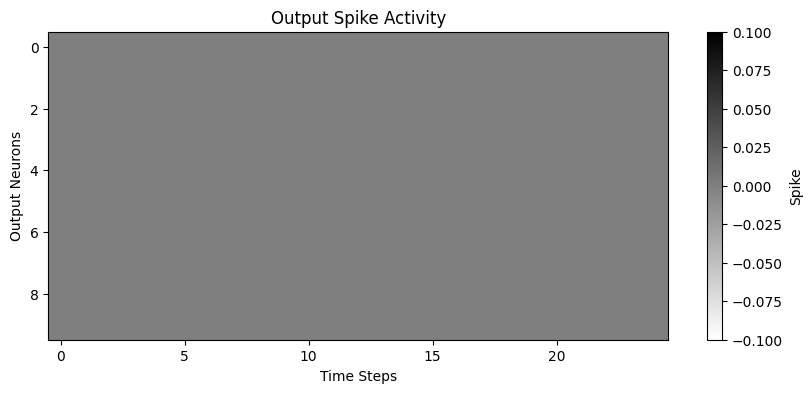

In [ ]:

# Visualize Output Spikes

sample_idx = 0

output_spikes = spk_out[:, sample_idx, :].detach().cpu()

plt.figure(figsize=(10,4))

plt.imshow(output_spikes.T, aspect='auto', cmap='binary')

plt.xlabel("Time Steps")
plt.ylabel("Output Neurons")
plt.title("Output Spike Activity")

plt.colorbar(label="Spike")

plt.show()

In [ ]:
import torch.optim as optim

# Loss Function
loss_fn = SF.ce_count_loss()

# Optimizer
optimizer = optim.Adam(net.parameters(), lr=1e-3)

print("Loss and optimizer initialized successfully!")

Loss and optimizer initialized successfully!


In [ ]:

# Training Parameters

num_epochs = 50
num_steps = 25

# Store metrics
train_loss_hist = []
train_acc_hist = []


# Training Loop
for epoch in range(num_epochs):

    net.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in mnist_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten images
        data = data.view(data.size(0), -1)

        # Latency encoding
        # Clamp to prevent fully-saturated pixels causing all-timestep spiking
        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Prediction from spike counts
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(mnist_loader)
    epoch_acc = 100 * correct / total

    train_loss_hist.append(epoch_loss)
    train_acc_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/50] Loss: 0.4757 Accuracy: 84.38%
Epoch [2/50] Loss: 0.2240 Accuracy: 93.44%
Epoch [3/50] Loss: 0.1774 Accuracy: 94.76%
Epoch [4/50] Loss: 0.1455 Accuracy: 95.70%
Epoch [5/50] Loss: 0.1212 Accuracy: 96.36%
Epoch [6/50] Loss: 0.1030 Accuracy: 96.98%
Epoch [7/50] Loss: 0.0911 Accuracy: 97.32%
Epoch [8/50] Loss: 0.0772 Accuracy: 97.71%
Epoch [9/50] Loss: 0.0716 Accuracy: 97.80%
Epoch [10/50] Loss: 0.0620 Accuracy: 98.14%
Epoch [11/50] Loss: 0.0580 Accuracy: 98.28%
Epoch [12/50] Loss: 0.0509 Accuracy: 98.42%
Epoch [13/50] Loss: 0.0455 Accuracy: 98.65%
Epoch [14/50] Loss: 0.0425 Accuracy: 98.77%
Epoch [15/50] Loss: 0.0373 Accuracy: 98.89%
Epoch [16/50] Loss: 0.0338 Accuracy: 99.00%
Epoch [17/50] Loss: 0.0321 Accuracy: 99.06%
Epoch [18/50] Loss: 0.0289 Accuracy: 99.10%
Epoch [19/50] Loss: 0.0280 Accuracy: 99.11%
Epoch [20/50] Loss: 0.0240 Accuracy: 99.33%
Epoch [21/50] Loss: 0.0239 Accuracy: 99.30%
Epoch [22/50] Loss: 0.0211 Accuracy: 99.39%
Epoch [23/50] Loss: 0.0196 Accuracy: 99.4

In [ ]:

# Evaluation on Test Set

net.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in mnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net(spike_data)

        # Prediction
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 97.40%


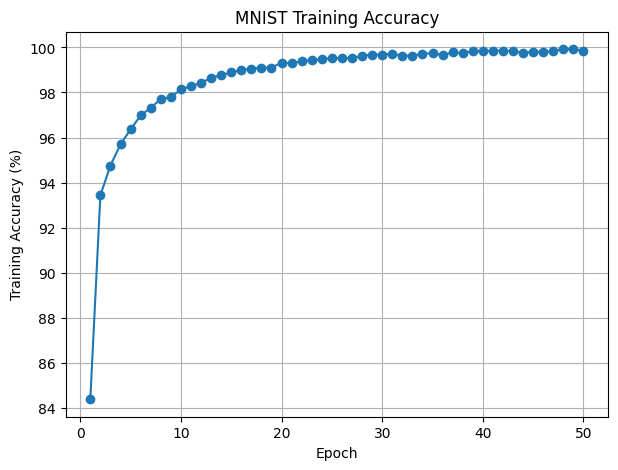

In [ ]:

# Plot Accuracy Curve

plt.figure(figsize=(7,5))

plt.plot(range(1, num_epochs+1), train_acc_hist, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("MNIST Training Accuracy")

plt.grid(True)

plt.show()

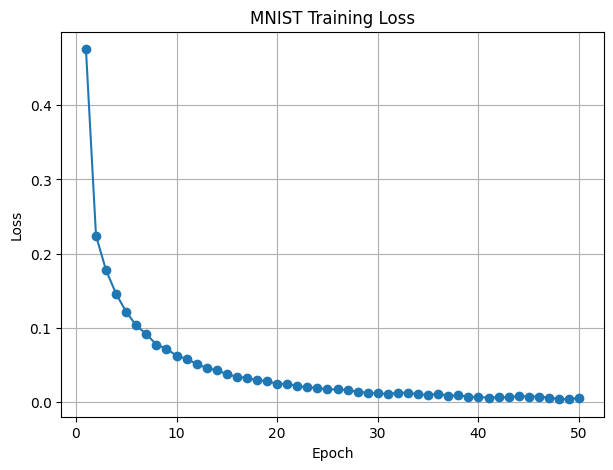

In [ ]:

# Plot Loss Curve

plt.figure(figsize=(7,5))

plt.plot(range(1, num_epochs+1), train_loss_hist, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")

plt.grid(True)

plt.show()

In [ ]:

# Create NEW Network

net_aug = SNN().to(device)

# Optimizer
optimizer_aug = optim.Adam(net_aug.parameters(), lr=1e-3)

# Training history
train_loss_aug_hist = []
train_acc_aug_hist = []

# Train on AUGMENTED MNIST

num_epochs = 50

for epoch in range(num_epochs):

    net_aug.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in mnist_aug_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        # Clamp to prevent fully-saturated pixels causing all-timestep spiking
        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_aug(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_aug.zero_grad()
        loss.backward()
        optimizer_aug.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(mnist_aug_loader)
    epoch_acc = 100 * correct / total

    train_loss_aug_hist.append(epoch_loss)
    train_acc_aug_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/50] Loss: 0.8825 Accuracy: 70.50%
Epoch [2/50] Loss: 0.3676 Accuracy: 88.50%
Epoch [3/50] Loss: 0.2772 Accuracy: 91.38%
Epoch [4/50] Loss: 0.2356 Accuracy: 92.73%
Epoch [5/50] Loss: 0.2168 Accuracy: 93.44%
Epoch [6/50] Loss: 0.1970 Accuracy: 94.01%
Epoch [7/50] Loss: 0.1825 Accuracy: 94.43%
Epoch [8/50] Loss: 0.1711 Accuracy: 94.75%
Epoch [9/50] Loss: 0.1639 Accuracy: 94.98%
Epoch [10/50] Loss: 0.1571 Accuracy: 95.25%
Epoch [11/50] Loss: 0.1501 Accuracy: 95.38%
Epoch [12/50] Loss: 0.1434 Accuracy: 95.57%
Epoch [13/50] Loss: 0.1379 Accuracy: 95.69%
Epoch [14/50] Loss: 0.1329 Accuracy: 95.95%
Epoch [15/50] Loss: 0.1272 Accuracy: 96.14%
Epoch [16/50] Loss: 0.1269 Accuracy: 96.13%
Epoch [17/50] Loss: 0.1247 Accuracy: 96.22%
Epoch [18/50] Loss: 0.1205 Accuracy: 96.33%
Epoch [19/50] Loss: 0.1186 Accuracy: 96.40%
Epoch [20/50] Loss: 0.1183 Accuracy: 96.32%
Epoch [21/50] Loss: 0.1156 Accuracy: 96.52%
Epoch [22/50] Loss: 0.1116 Accuracy: 96.54%
Epoch [23/50] Loss: 0.1120 Accuracy: 96.5

In [ ]:

# Test Accuracy (Augmented Model)

net_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in mnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_aug(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

aug_test_acc = 100 * correct / total

print(f"Augmented MNIST Test Accuracy: {aug_test_acc:.2f}%")

Augmented MNIST Test Accuracy: 97.98%


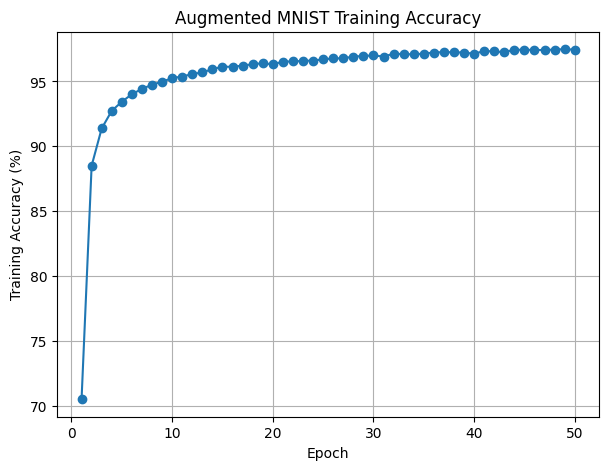

In [ ]:

# Augmented MNIST Training Accuracy

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Augmented MNIST Training Accuracy")

plt.grid(True)

plt.show()

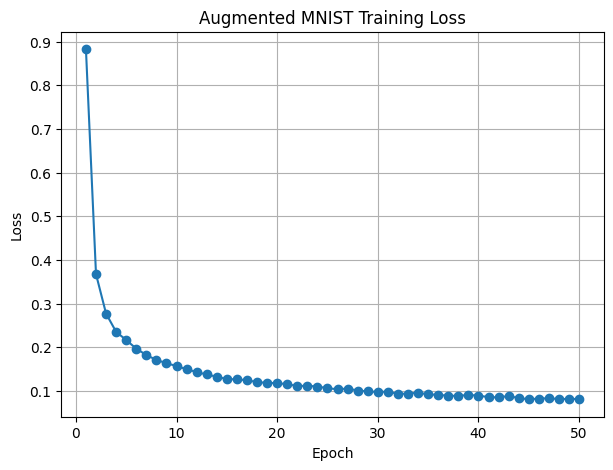

In [ ]:

# Augmented MNIST Training Loss

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented MNIST Training Loss")

plt.grid(True)

plt.show()

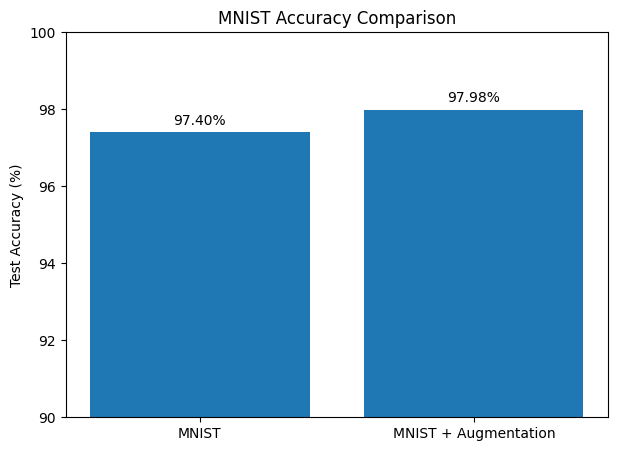

In [ ]:

# Compare Test Accuracies

labels = ["MNIST", "MNIST + Augmentation"]
accuracies = [test_acc, aug_test_acc]

plt.figure(figsize=(7,5))

plt.bar(labels, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("MNIST Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(90, 100)

plt.show()

In [ ]:

# NEW NETWORK FOR FASHION-MNIST

net_fmnist = SNN().to(device)

optimizer_fmnist = optim.Adam(
    net_fmnist.parameters(),
    lr=1e-3
)

# History
train_loss_fmnist_hist = []
train_acc_fmnist_hist = []


# Train on Fashion-MNIST

num_epochs = 50

for epoch in range(num_epochs):

    net_fmnist.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in fmnist_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency Encoding
        # Clamp to prevent fully-saturated pixels causing all-timestep spiking
        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_fmnist(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_fmnist.zero_grad()
        loss.backward()
        optimizer_fmnist.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(fmnist_loader)
    epoch_acc = 100 * correct / total

    train_loss_fmnist_hist.append(epoch_loss)
    train_acc_fmnist_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/50] Loss: 0.6174 Accuracy: 77.99%
Epoch [2/50] Loss: 0.4158 Accuracy: 85.15%
Epoch [3/50] Loss: 0.3758 Accuracy: 86.39%
Epoch [4/50] Loss: 0.3454 Accuracy: 87.45%
Epoch [5/50] Loss: 0.3239 Accuracy: 88.29%
Epoch [6/50] Loss: 0.3107 Accuracy: 88.75%
Epoch [7/50] Loss: 0.2950 Accuracy: 89.29%
Epoch [8/50] Loss: 0.2863 Accuracy: 89.58%
Epoch [9/50] Loss: 0.2761 Accuracy: 89.99%
Epoch [10/50] Loss: 0.2668 Accuracy: 90.35%
Epoch [11/50] Loss: 0.2578 Accuracy: 90.63%
Epoch [12/50] Loss: 0.2458 Accuracy: 91.12%
Epoch [13/50] Loss: 0.2410 Accuracy: 91.22%
Epoch [14/50] Loss: 0.2269 Accuracy: 91.85%
Epoch [15/50] Loss: 0.2206 Accuracy: 91.97%
Epoch [16/50] Loss: 0.2121 Accuracy: 92.34%
Epoch [17/50] Loss: 0.1996 Accuracy: 92.89%
Epoch [18/50] Loss: 0.1989 Accuracy: 92.83%
Epoch [19/50] Loss: 0.1860 Accuracy: 93.31%
Epoch [20/50] Loss: 0.1840 Accuracy: 93.36%
Epoch [21/50] Loss: 0.1771 Accuracy: 93.66%
Epoch [22/50] Loss: 0.1728 Accuracy: 93.92%
Epoch [23/50] Loss: 0.1649 Accuracy: 94.0

In [ ]:

# Test Accuracy on Fashion-MNIST

net_fmnist.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in fmnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_fmnist(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

fmnist_test_acc = 100 * correct / total

print(f"Fashion-MNIST Test Accuracy: {fmnist_test_acc:.2f}%")

Fashion-MNIST Test Accuracy: 87.54%


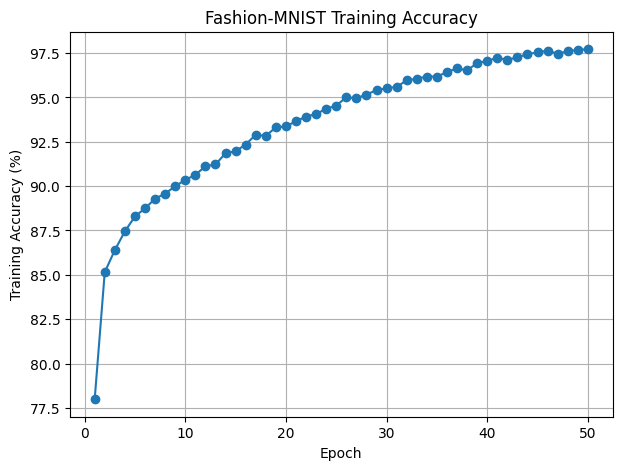

In [ ]:

# Fashion-MNIST Accuracy Curve

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_fmnist_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Fashion-MNIST Training Accuracy")

plt.grid(True)

plt.show()

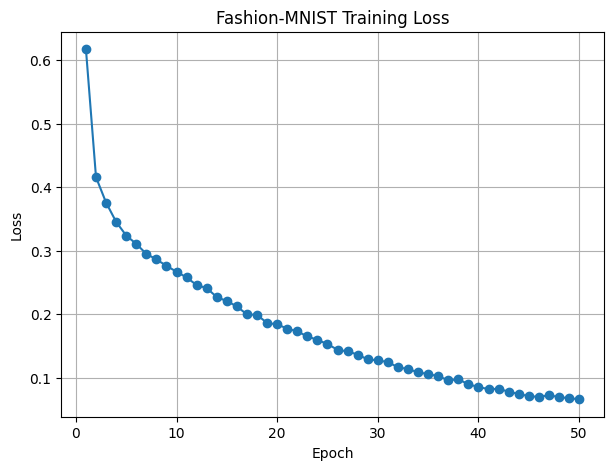

In [ ]:

# Fashion-MNIST Loss Curve

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_fmnist_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fashion-MNIST Training Loss")

plt.grid(True)

plt.show()

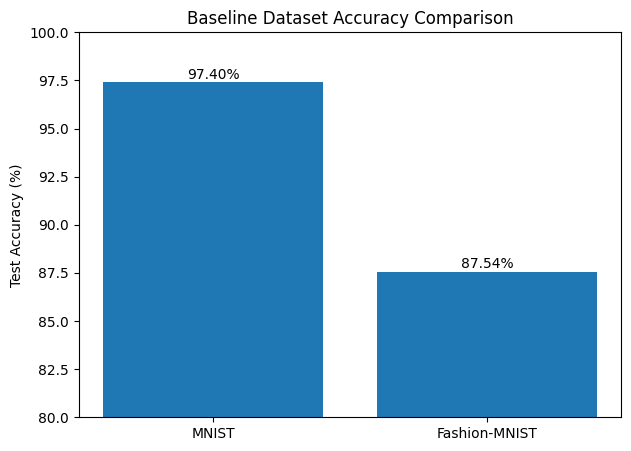

In [ ]:

# Baseline Dataset Comparison

datasets_names = ["MNIST", "Fashion-MNIST"]
baseline_accuracies = [test_acc, fmnist_test_acc]

plt.figure(figsize=(7,5))

plt.bar(datasets_names, baseline_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Baseline Dataset Accuracy Comparison")

for i, v in enumerate(baseline_accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(80, 100)

plt.show()

In [ ]:

# NEW NETWORK FOR AUGMENTED F-MNIST

net_fmnist_aug = SNN().to(device)

optimizer_fmnist_aug = optim.Adam(
    net_fmnist_aug.parameters(),
    lr=1e-3
)

# History
train_loss_fmnist_aug_hist = []
train_acc_fmnist_aug_hist = []


# Train on Augmented Fashion-MNIST

num_epochs = 50

for epoch in range(num_epochs):

    net_fmnist_aug.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in fmnist_aug_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        # Clamp to prevent fully-saturated pixels causing all-timestep spiking
        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_fmnist_aug(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_fmnist_aug.zero_grad()
        loss.backward()
        optimizer_fmnist_aug.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(fmnist_aug_loader)
    epoch_acc = 100 * correct / total

    train_loss_fmnist_aug_hist.append(epoch_loss)
    train_acc_fmnist_aug_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/50] Loss: 0.8954 Accuracy: 66.81%
Epoch [2/50] Loss: 0.6322 Accuracy: 76.10%
Epoch [3/50] Loss: 0.5754 Accuracy: 78.45%
Epoch [4/50] Loss: 0.5501 Accuracy: 79.36%
Epoch [5/50] Loss: 0.5322 Accuracy: 80.21%
Epoch [6/50] Loss: 0.5130 Accuracy: 80.87%
Epoch [7/50] Loss: 0.4950 Accuracy: 81.43%
Epoch [8/50] Loss: 0.4813 Accuracy: 82.10%
Epoch [9/50] Loss: 0.4773 Accuracy: 82.11%
Epoch [10/50] Loss: 0.4675 Accuracy: 82.45%
Epoch [11/50] Loss: 0.4604 Accuracy: 82.79%
Epoch [12/50] Loss: 0.4560 Accuracy: 83.21%
Epoch [13/50] Loss: 0.4540 Accuracy: 83.00%
Epoch [14/50] Loss: 0.4465 Accuracy: 83.36%
Epoch [15/50] Loss: 0.4480 Accuracy: 83.43%
Epoch [16/50] Loss: 0.4421 Accuracy: 83.53%
Epoch [17/50] Loss: 0.4417 Accuracy: 83.58%
Epoch [18/50] Loss: 0.4303 Accuracy: 84.00%
Epoch [19/50] Loss: 0.4277 Accuracy: 84.19%
Epoch [20/50] Loss: 0.4292 Accuracy: 84.10%
Epoch [21/50] Loss: 0.4279 Accuracy: 84.33%
Epoch [22/50] Loss: 0.4261 Accuracy: 84.18%
Epoch [23/50] Loss: 0.4180 Accuracy: 84.6

In [ ]:

# Test Accuracy
# Augmented Fashion-MNIST


net_fmnist_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in fmnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        data = data.clamp(0, 1 - 1e-6)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_fmnist_aug(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

fmnist_aug_test_acc = 100 * correct / total

print(f"Augmented Fashion-MNIST Test Accuracy: {fmnist_aug_test_acc:.2f}%")

Augmented Fashion-MNIST Test Accuracy: 86.49%


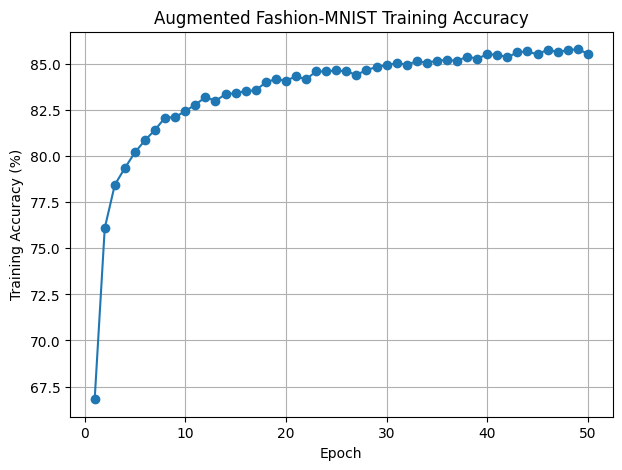

In [ ]:

# Augmented Fashion-MNIST Accuracy

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_fmnist_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Augmented Fashion-MNIST Training Accuracy")

plt.grid(True)

plt.show()

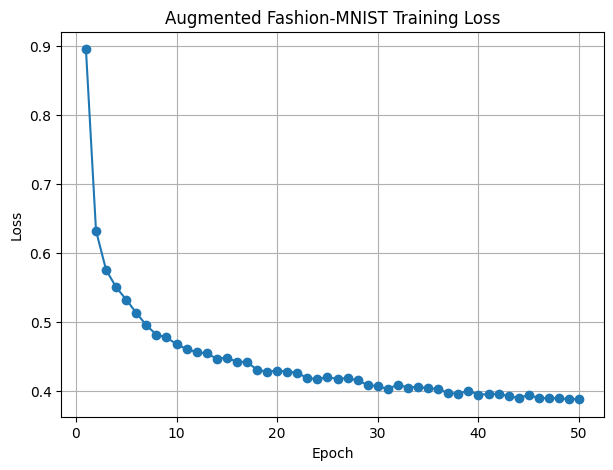

In [ ]:

# Augmented Fashion-MNIST Loss


plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_fmnist_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented Fashion-MNIST Training Loss")

plt.grid(True)

plt.show()

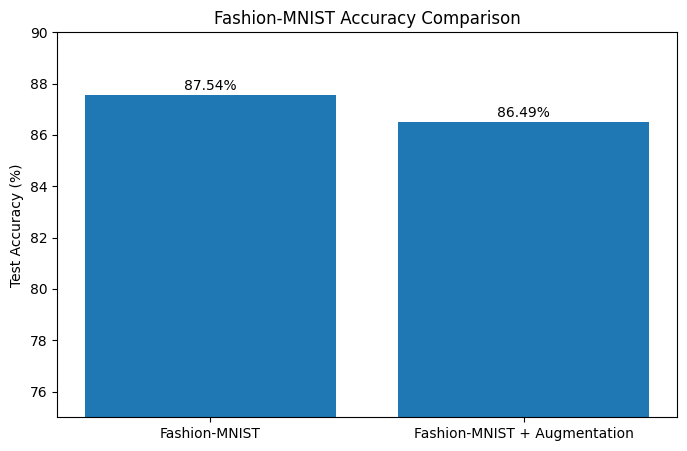

In [ ]:

# Fashion-MNIST Comparison

labels = [
    "Fashion-MNIST",
    "Fashion-MNIST + Augmentation"
]

accuracies = [
    fmnist_test_acc,
    fmnist_aug_test_acc
]

plt.figure(figsize=(8,5))

plt.bar(labels, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Fashion-MNIST Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(75, 90)

plt.show()

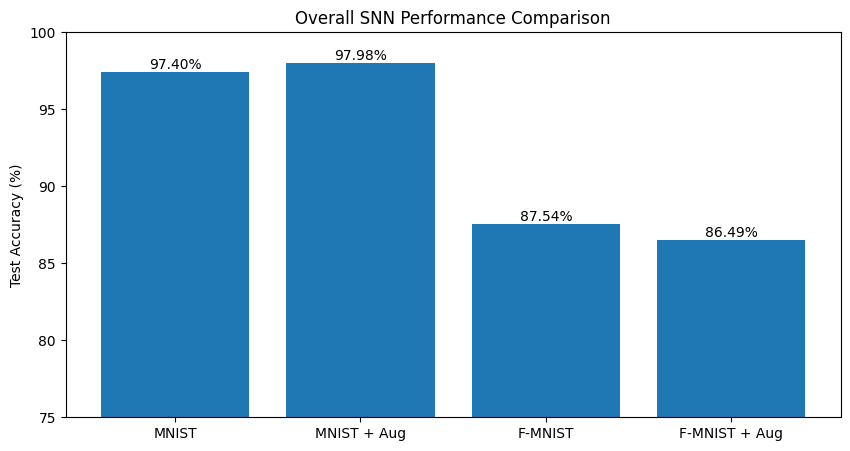

In [ ]:

# Final Overall Comparison

experiment_names = [
    "MNIST",
    "MNIST + Aug",
    "F-MNIST",
    "F-MNIST + Aug"
]

final_accuracies = [
    test_acc,
    aug_test_acc,
    fmnist_test_acc,
    fmnist_aug_test_acc
]

plt.figure(figsize=(10,5))

plt.bar(experiment_names, final_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Overall SNN Performance Comparison")

for i, v in enumerate(final_accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(75, 100)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np


# Confusion Matrix Function

def plot_confusion_matrix(
    model,
    loader,
    class_labels,
    title
):

    all_preds = []
    all_targets = []

    model.eval()

    with torch.no_grad():

        for data, targets in loader:

            data = data.to(device)
            targets = targets.to(device)

            # Flatten
            data = data.view(data.size(0), -1)

            # Latency Encoding
            spike_data = spikegen.latency(
                data,
                num_steps=num_steps,
                normalize=True,
                linear=True
            )

            # Forward Pass
            spk_out, mem_out = model(spike_data)

            spike_counts = spk_out.sum(dim=0)
            predicted = spike_counts.argmax(dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Create confusion matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Plot
    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.show()

In [34]:
# MNIST labels
mnist_labels = [
    "0","1","2","3","4",
    "5","6","7","8","9"
]

# Fashion-MNIST labels
fashion_labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

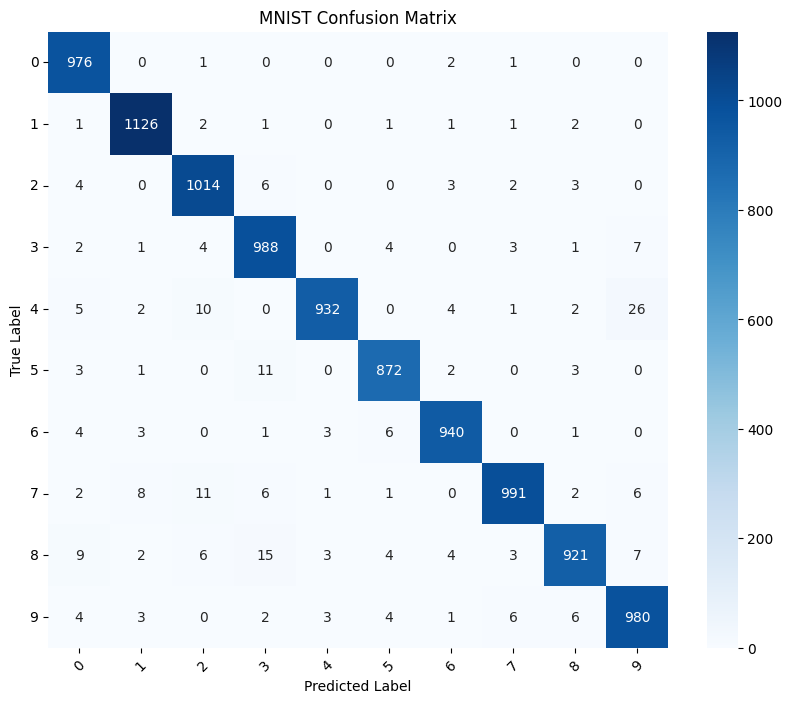

In [35]:
plot_confusion_matrix(
    net,
    mnist_test_loader,
    mnist_labels,
    "MNIST Confusion Matrix"
)

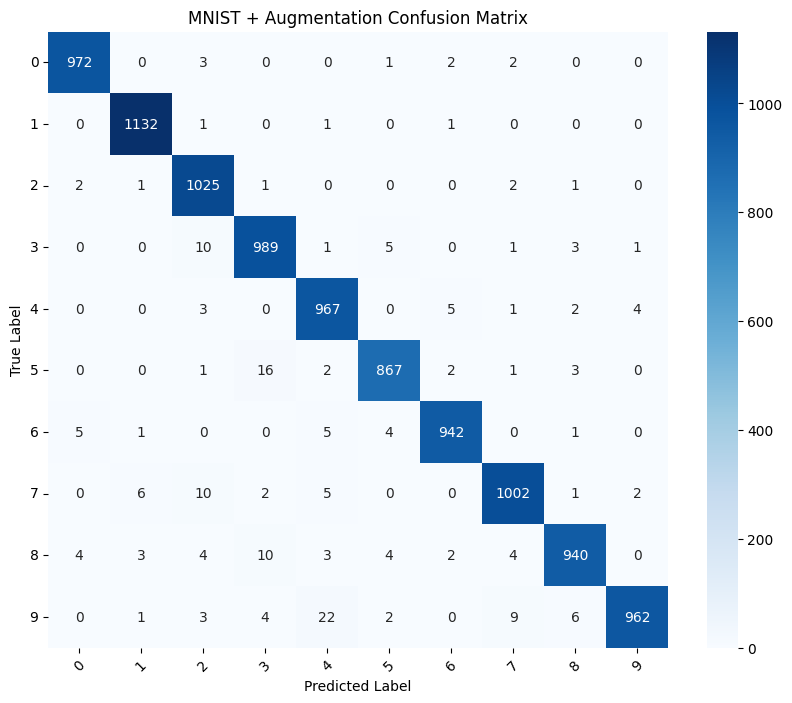

In [36]:
plot_confusion_matrix(
    net_aug,
    mnist_test_loader,
    mnist_labels,
    "MNIST + Augmentation Confusion Matrix"
)

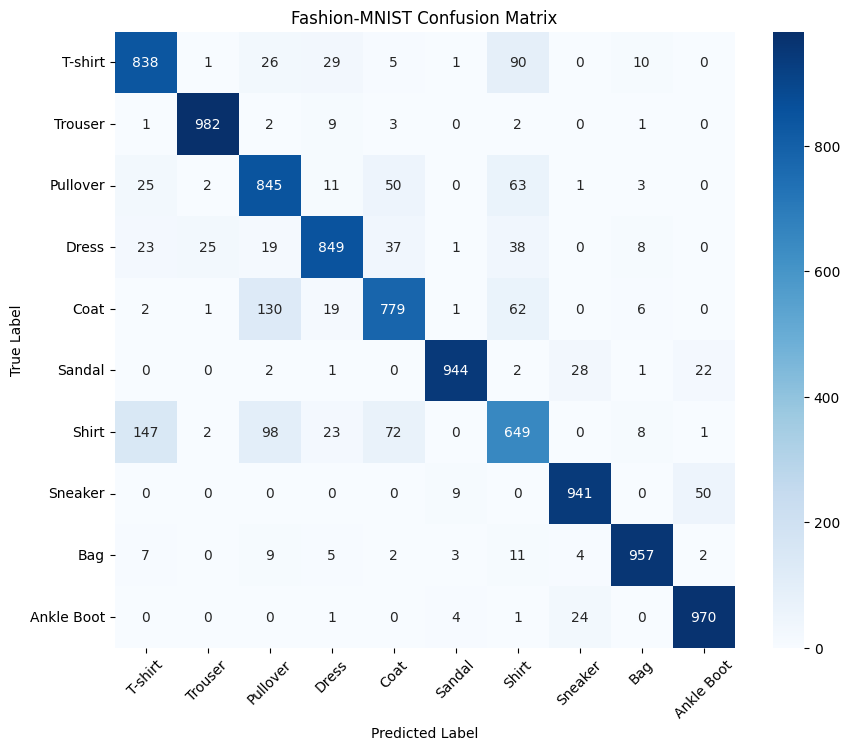

In [37]:
plot_confusion_matrix(
    net_fmnist,
    fmnist_test_loader,
    fashion_labels,
    "Fashion-MNIST Confusion Matrix"
)

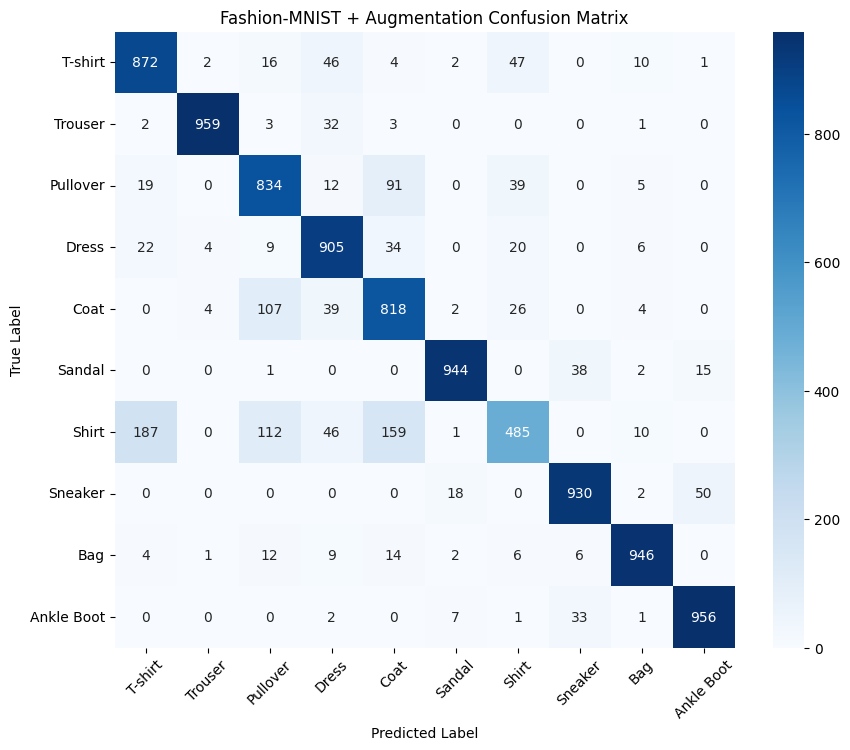

In [38]:
plot_confusion_matrix(
    net_fmnist_aug,
    fmnist_test_loader,
    fashion_labels,
    "Fashion-MNIST + Augmentation Confusion Matrix"
)

In [ ]:
import pandas as pd


# Final Results Table

results_df = pd.DataFrame({
    "Experiment": [
        "MNIST",
        "MNIST + Augmentation",
        "Fashion-MNIST",
        "Fashion-MNIST + Augmentation"
    ],
    "Test Accuracy (%)": [
        round(test_acc, 2),
        round(aug_test_acc, 2),
        round(fmnist_test_acc, 2),
        round(fmnist_aug_test_acc, 2)
    ]
})

print(results_df)

                     Experiment  Test Accuracy (%)
0                         MNIST              97.40
1          MNIST + Augmentation              97.98
2                 Fashion-MNIST              87.54
3  Fashion-MNIST + Augmentation              86.49


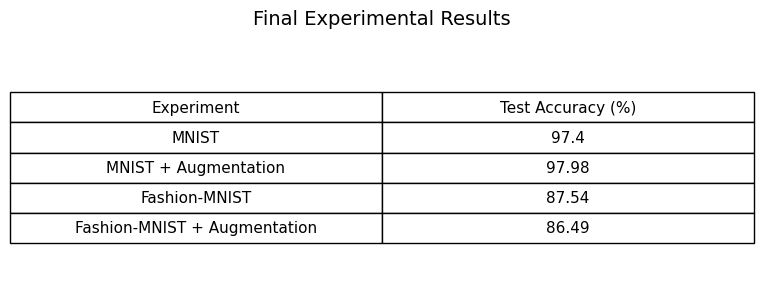

In [ ]:

# Visual Results Table

import pandas as pd

# Create dataframe
results_df = pd.DataFrame({
    "Experiment": [
        "MNIST",
        "MNIST + Augmentation",
        "Fashion-MNIST",
        "Fashion-MNIST + Augmentation"
    ],
    "Test Accuracy (%)": [
        round(test_acc, 2),
        round(aug_test_acc, 2),
        round(fmnist_test_acc, 2),
        round(fmnist_aug_test_acc, 2)
    ]
})


# Plot Styled Table

fig, ax = plt.subplots(figsize=(8,3))

ax.axis('off')

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title(
    "Final Experimental Results",
    fontsize=14,
    pad=20
)

plt.show()